In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\HP\Documents\GitHub\glovo-spec-analysis\data\glovo_reviews_raw.csv")

In [8]:
df.head()

,review_id,user,rating,date,text,thumbs_up
0,9545b388-0a2f-4f5e-a001-f50f392b7b11,Joel Ibanga,5,07/08/2026 14:38,very fast,0
1,7e5e2547-f5df-4cf5-be4f-7c4ba7995810,joy olayinka,4,07/08/2026 12:52,satisfactory,0
2,5a8e3559-772a-41f0-b172-1e7743579b52,Emmanuel Otukol,5,07/08/2026 11:28,Cool,0
3,b34e020e-d85b-4b97-921e-4efe5c30ea2b,Tudor Radutu,1,07/08/2026 10:55,"worst service ever, overpriced delivery fees, ...",0
4,63b022d9-b5d2-4222-b060-cf53beb95d85,Colines Okelo,5,07/08/2026 10:29,cool,0


In [9]:
df.columns

Index(['review_id', 'user', 'rating', 'date', 'text', 'thumbs_up'], dtype='object')

In [10]:
df['review_lower'] = df['text'].str.lower()

In [11]:
df['review_lower']

0                                              very fast
1                                           satisfactory
2                                                   cool
3      worst service ever, overpriced delivery fees, ...
4                                                   cool
                             ...                        
595                                            very good
596                                             nice one
597                 expand your delivery location reach.
598    why would meals cost extra if i'm already payi...
599    scamers, they say we will refund, and then the...
Name: review_lower, Length: 600, dtype: object

In [12]:
df['is_payment'] = df['review_lower'].str.contains('refund|refunded|charge|charged|debit|debitted|money|bank|card|compensation|scam|scammed|stole|stolen|credit')

In [13]:
df['is_payment'].value_counts()

is_payment
False    527
True      73
Name: count, dtype: int64

In [14]:
df[df['is_payment'] == True]['rating'].mean()

1.3424657534246576

In [15]:
df[df['is_payment'] == False]['rating'].mean()

3.81404174573055

In [16]:
df['is_order_accuracy'] = df['review_lower'].str.contains('wrong|missing|didn\'t arrive|never arrived|not delivered|swapped|incomplete')

In [17]:
df[df['is_order_accuracy'] == True]['rating'].mean()

1.411764705882353

In [18]:
df[df['is_order_accuracy'] == False]['rating'].mean()

3.574614065180103

In [19]:
df['is_delivery_time'] = df['review_lower'].str.contains('late|slow|delay|delayed|waiting|hours|wait')

In [20]:
df[df['is_delivery_time'] == True]['rating'].mean()

1.5

In [21]:
df[df['is_delivery_time'] == False]['rating'].mean()

3.619298245614035

In [22]:
df['is_support'] = df['review_lower'].str.contains('support|customer service|customer care|agent|chat|unhelpful|no response|ignored')

In [23]:
df[df['is_support'] == True]['rating'].mean()

1.7755102040816326

In [24]:
df[df['is_support'] == False]['rating'].mean()

3.6678765880217785

In [25]:
df['is_order_accuracy'].value_counts()

is_order_accuracy
False    583
True      17
Name: count, dtype: int64

In [26]:
df['is_delivery_time'].value_counts()

is_delivery_time
False    570
True      30
Name: count, dtype: int64

In [27]:
df['is_support'].value_counts()

is_support
False    551
True      49
Name: count, dtype: int64

In [28]:
df[df['is_order_accuracy'] == False]['text']. sample(40)

149                          best food delivery app ever
2                                                   Cool
184    this app is one of the greatest and their deli...
394    ponad 3 godzin czekałem na zamówienie które pi...
79                                                  Nice
84                                          Excellent 👍👌
186                                                 Fast
139                                 one stop online shop
585    When 2 orders of different customers are carri...
168    Riders often steal your food and it never come...
102                                             very bad
413    I ordered chicken tikka and it's the worst.wha...
439                            fast delivery. very good!
215    nice app I could order from the hospital and i...
0                                              very fast
69                              good and prompt service.
469                                         Good service
50     my first impression was 

In [29]:
categories = ['Payment/Refund', 'Order Accuracy', 'Delivery time', 'Support']
avg_rating = [1.34, 1.41, 1.50, 1.78]
counts = [73, 17, 30, 49]

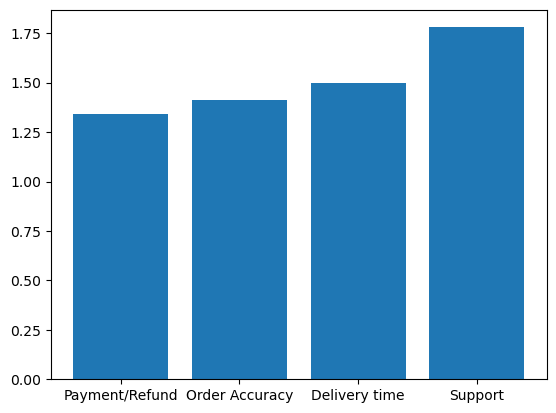

In [30]:
plt.bar(categories, avg_rating)
plt.show()

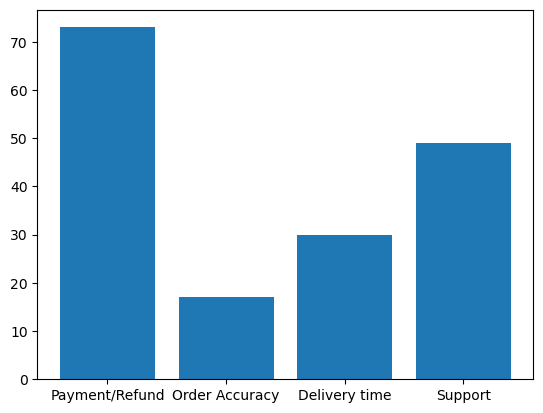

In [31]:
plt.bar(categories, counts)
plt.show()

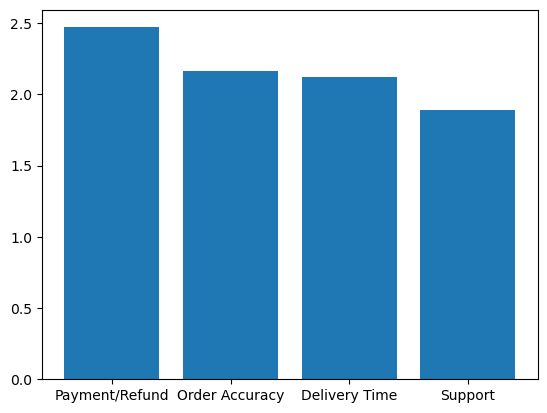

In [32]:
categories = ['Payment/Refund', 'Order Accuracy', 'Delivery Time', 'Support']
drops = [2.47, 2.16, 2.12, 1.89]  # baseline avg minus category avg

plt.bar(categories, drops)
plt.show()

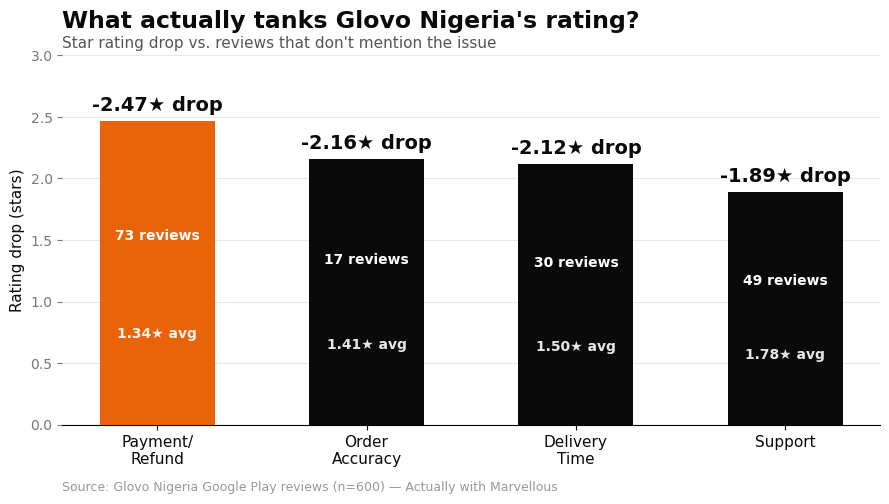

In [33]:
# ForgeLabs brand colors
ORANGE = "#E8630A"
BLACK = "#0A0A0A"
WHITE = "#FFFFFF"
GREY = "#B0B0B0"

categories = ['Payment/\nRefund', 'Order\nAccuracy', 'Delivery\nTime', 'Support']
drops = [2.47, 2.16, 2.12, 1.89]
counts = [73, 17, 30, 49]
avg_ratings = [1.34, 1.41, 1.50, 1.78]

colors = [ORANGE if i == 0 else BLACK for i in range(len(categories))]

fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

bars = ax.bar(categories, drops, color=colors, width=0.55, zorder=3)

for bar, drop, count, avg in zip(bars, drops, counts, avg_ratings):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05,
            f"-{drop:.2f}★ drop", ha='center', va='bottom',
            fontsize=14, fontweight='bold', color=BLACK)
    ax.text(bar.get_x() + bar.get_width() / 2, height * 0.62,
            f"{count} reviews", ha='center', va='center',
            fontsize=10, color=WHITE, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, height * 0.30,
            f"{avg:.2f}★ avg", ha='center', va='center',
            fontsize=10, color=WHITE, fontweight='bold', alpha=0.9)

ax.set_title("What actually tanks Glovo Nigeria's rating?", fontsize=17,
             fontweight='bold', color=BLACK, pad=20, loc='left')
ax.text(0, 1.02, "Star rating drop vs. reviews that don't mention the issue",
        transform=ax.transAxes, fontsize=11, color='#555555')

ax.set_ylabel("Rating drop (stars)", fontsize=11, color=BLACK)
ax.set_ylim(0, 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', labelsize=11, colors=BLACK)
ax.tick_params(axis='y', labelsize=10, colors='#777777')
ax.grid(axis='y', color=GREY, alpha=0.3, zorder=0)

ax.text(0, -0.18, "Source: Glovo Nigeria Google Play reviews (n=600) — Actually with Marvellous",
        transform=ax.transAxes, fontsize=9, color='#999999')

plt.tight_layout()
plt.savefig('glovo_chart.png', dpi=200, facecolor=WHITE, bbox_inches='tight')